# Ghost Scale Simulation — walkthrough

This notebook runs **E1 (the generative crash)** and **E2 (confident disagreement — the
hallucination signature)** end to end, and narrates what each step shows.

It runs at reduced (`--quick`-equivalent) scale so it completes in a minute or two on a
clean environment; the published figures use the full 200-observer / 20-seed scale.

> Everything is seeded. The point of this build is that the effects have matching **nulls**
> (see `tests/test_nulls.py`) — synthetic content here is *structured but goal-unidentifiable*,
> not noise, and the observer has **no preference** over provenance or signal.


In [1]:
# Resolve paths from the repo root whether launched here or in notebooks/
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from ghostscale.config import load_config
from ghostscale import generative_model as gmod, creators, metrics, constants as K
cfg = load_config(quick=True)
print('tiers:', K.PROVENANCE_NAMES)
print('alpha (intent-transmission = Ghost Scale opacity):', cfg.artifact_model.alpha.raw)


tiers: ['CREATOR', 'POLISHED', 'CURATOR', 'GHOST']
alpha (intent-transmission = Ghost Scale opacity): {'CREATOR': 1.0, 'POLISHED': 0.95, 'CURATOR': 0.6, 'GHOST': 0.05}


## 1. The generative model

`A[0]` (artifact features) mixes each tier's intent-transmission coefficient α with the
goal signature and the **structured, goal-independent** synthetic distribution. We check the
load-bearing invariants: goal signatures are distinguishable, the synthetic distribution is
structured (not high-entropy), and mutual information between features and goal falls
monotonically across tiers to ~0 for GHOST.


In [2]:
gm = gmod.build_shared_model(cfg)
info = gmod.check_signature_invariants(gm, cfg)
print('H(noise_free_synth) = %.3f nats   (uniform would be ln(8)=%.3f)' % (info['h_noise_free_synth'], np.log(8)))
print('pairwise JS(sig) min = %.3f  (> threshold %.2f)' % (min(info['js_pairs'].values()), cfg.artifact_model.js_threshold))
for p,name in enumerate(K.PROVENANCE_NAMES):
    mi = metrics.mutual_information_features_goal(gm.A[0], p, K.DEEP)
    h  = metrics.feature_entropy_given_provenance(gm.A[0], p, K.DEEP)
    print('  %-8s  MI(features;goal)=%.3f   H(features)=%.3f' % (name, mi, h))


H(noise_free_synth) = 1.515 nats   (uniform would be ln(8)=2.079)
pairwise JS(sig) min = 0.566  (> threshold 0.20)
  CREATOR   MI(features;goal)=1.089   H(features)=2.079
  POLISHED  MI(features;goal)=0.971   H(features)=2.078
  CURATOR   MI(features;goal)=0.451   H(features)=2.006
  GHOST     MI(features;goal)=0.014   H(features)=1.590


**Read this:** GHOST has near-zero MI (goal is unidentifiable) but *low* feature entropy —
structured, not noise. That distinction is the whole point (null N6 makes it a test).


## 2. Human creators are real agents

A human creator is a real pymdp agent whose reward-optimizing policy *produces* the
features — it is not a sampler of `sig[g]`. We verify post hoc that its emission distribution
reproduces the goal signature.


In [3]:
bank = creators.build_creator_bank(cfg, gm)
for g,c in bank.items():
    err = np.max(np.abs(c.emission_distribution() - gm.sig[g]))
    print('  creator goal G%d: max|p_emit - sig| = %.4f' % (g, err))


  creator goal G0: max|p_emit - sig| = 0.0000
  creator goal G1: max|p_emit - sig| = 0.0000
  creator goal G2: max|p_emit - sig| = 0.0000
  creator goal G3: max|p_emit - sig| = 0.0000


## 3. E1 — the generative crash

Each observer looks at one artifact (honest signal, κ=0.9). We measure how long it sustains
DEEP attention and how well it recovers the goal, by tier.


In [4]:
from ghostscale.experiments import e1_crash
summary = e1_crash.run(cfg, workers=1, make_fig=True)
digest = summary.groupby('tier').agg(cum_deep=('cum_deep','mean'),
        final_entropy=('final_goal_entropy','mean'), accuracy=('correct','mean')).reindex(K.PROVENANCE_NAMES)
digest.round(3)


,cum_deep,final_entropy,accuracy
tier,,,
CREATOR,1.567,0.129,0.950
POLISHED,1.817,0.118,1.000
CURATOR,2.783,0.373,0.950
GHOST,0.000,1.368,0.183


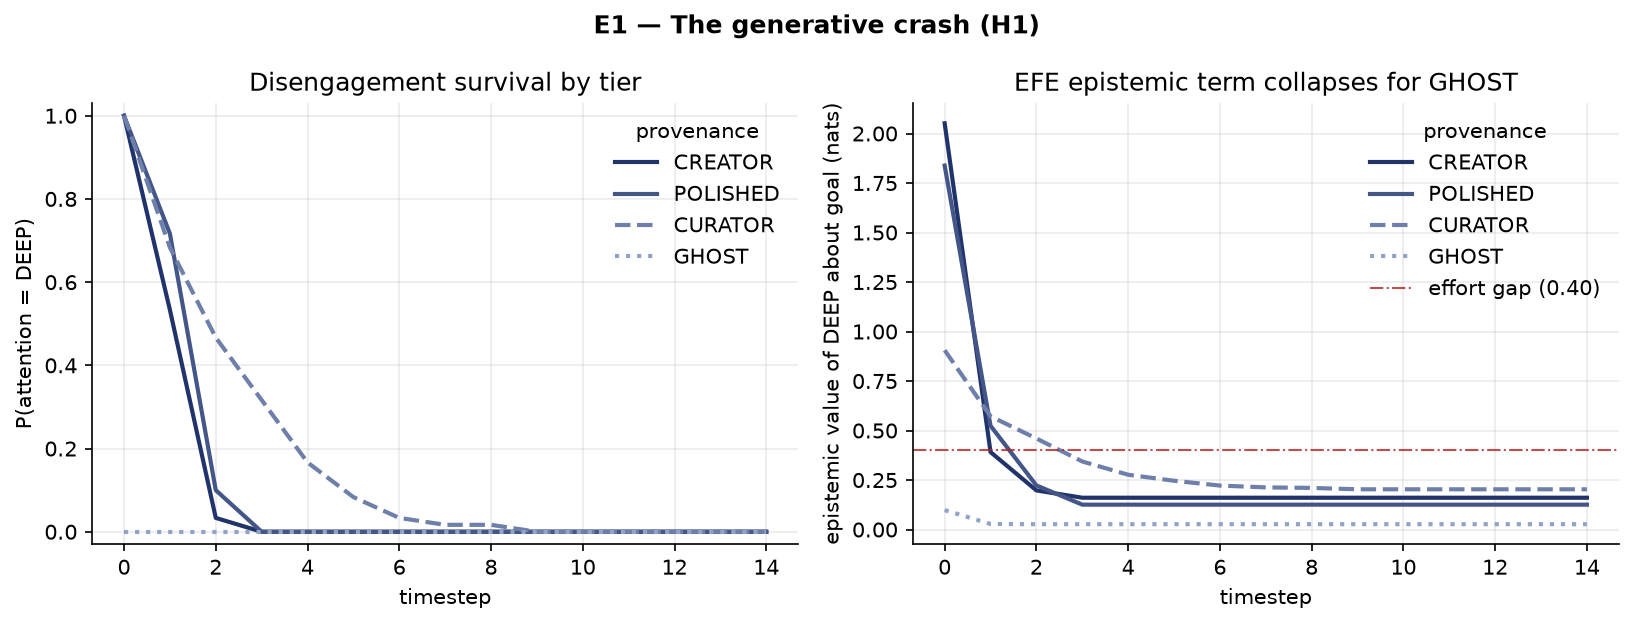

In [5]:
from IPython.display import Image
Image('figures/e1_crash.png')


**Read this:** GHOST disengages immediately and never recovers the goal (accuracy ≈ chance);
human tiers engage and recover it. The right panel shows the epistemic value of DEEP is a
*step function across tiers* — near-zero for GHOST from the start.


## 4. E2 — confident disagreement is the signature of hallucination

2×2: true origin {CREATOR, GHOST} × declared signal {SIG_CREATOR, SIG_GHOST}, forced DEEP
for the first *k* steps. All observers view the **same** true goal (inter-rater reliability),
so disagreement reflects hallucination, not different stimuli.


In [6]:
from ghostscale.experiments import e2_variance
e2_variance.run(cfg, workers=1, make_fig=True)
pd.read_csv('results/e2_cell_stats.csv').round(3)


,true_provenance,declared_signal,within,between,within_sd,between_sd
0,CREATOR,SIG_CREATOR,0.000,0.000,0.000,0.000
1,CREATOR,SIG_GHOST,0.099,0.000,0.028,0.000
2,GHOST,SIG_CREATOR,0.078,1.306,0.015,0.041
3,GHOST,SIG_GHOST,1.277,1.291,0.015,0.010


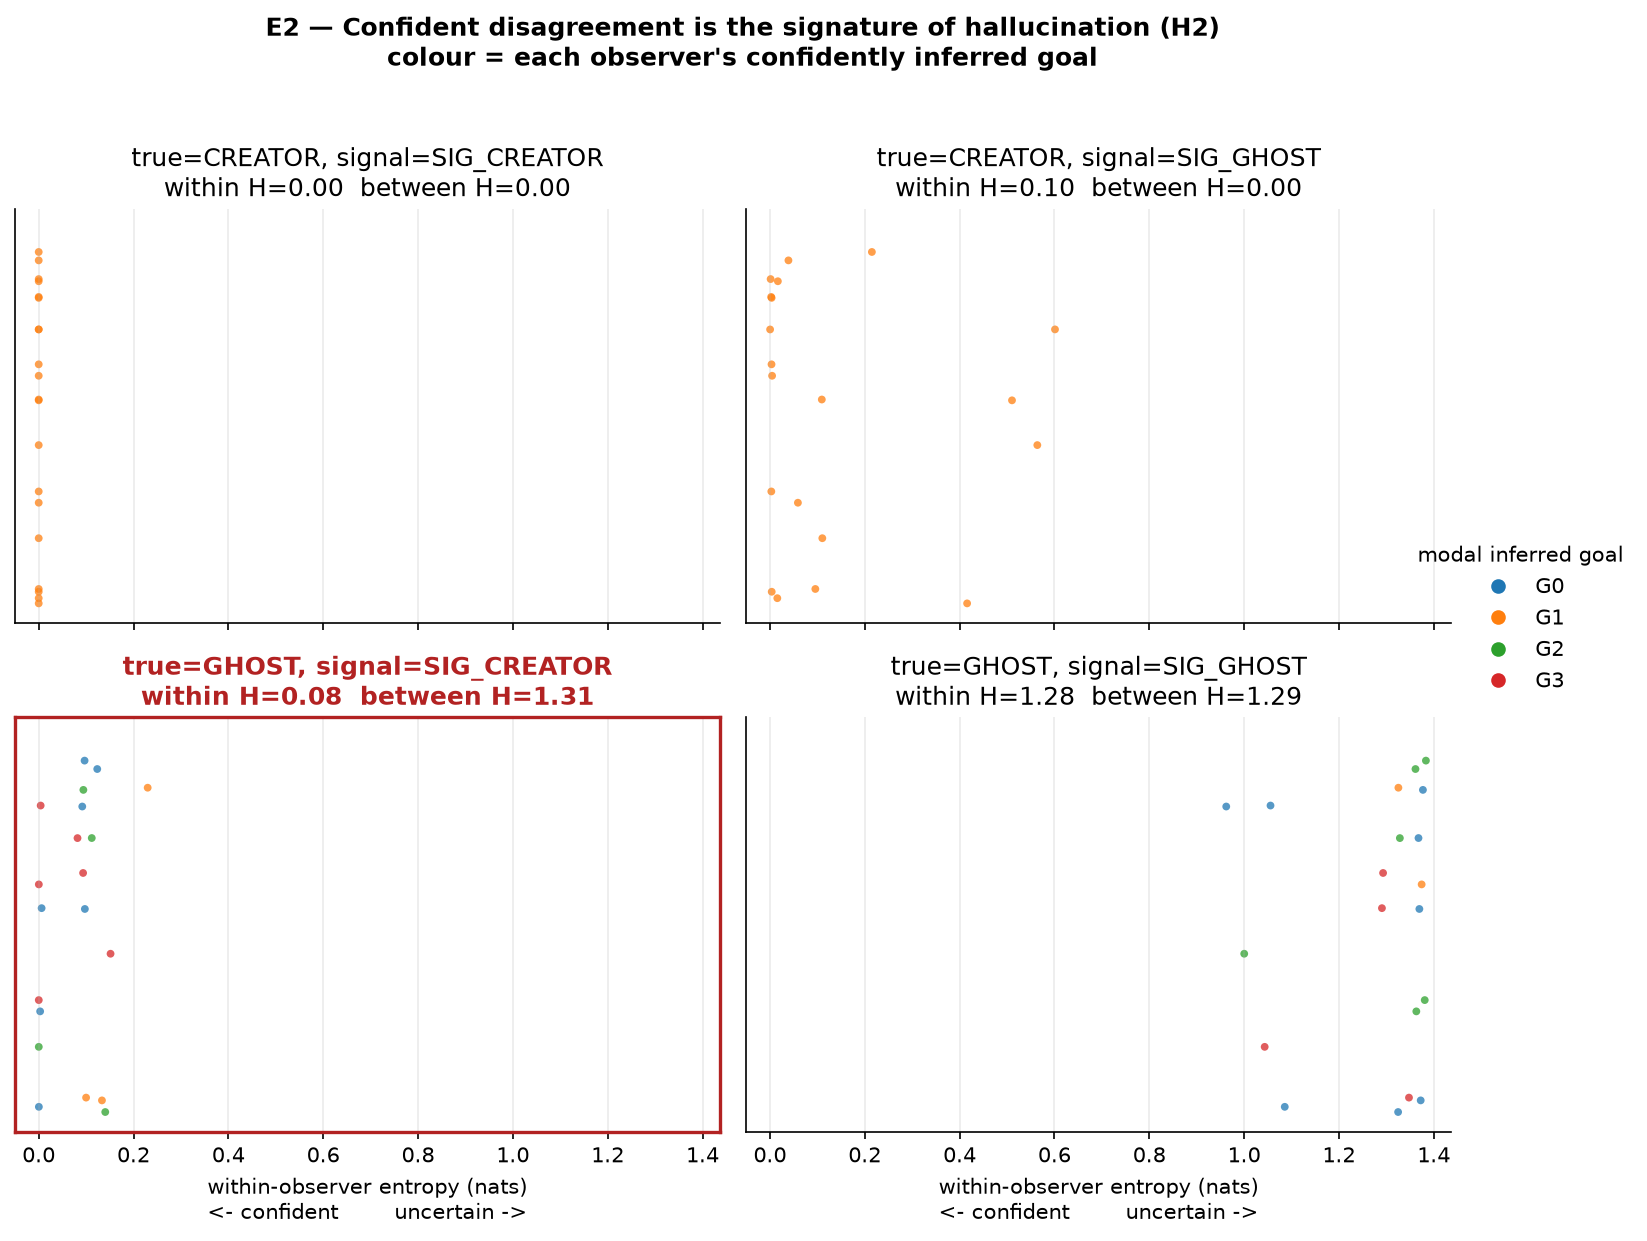

In [7]:
Image('figures/e2_variance.png')


**Read this — the headline.** In `(true=GHOST, signal=SIG_CREATOR)`: **within**-observer
entropy is low (every observer is confident) while **between**-observer entropy is near
maximal (they all disagree). That dissociation — confident *and* disagreeing — is
`R_hallucinated`. In `(true=GHOST, signal=SIG_GHOST)` the observer instead *keeps* its
uncertainty: trust is what converts preserved uncertainty into fabricated confidence.


---
See `RESULTS.md` for the full-scale numbers across all six experiments, the null-test
outcomes, and the documented deviations from the build spec.
